<a href="https://colab.research.google.com/github/Le2se0hy/FA_ProAn/blob/main/%ED%95%B8%EC%A6%88%EC%98%A8%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_4%EC%9E%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 핸즈온 머신러닝_4장 [모델 훈련]

가장 간단한 모델부터 시작 → 선형 회귀

이 모데을 훈련시키는 두 가지 방법을 설명
- 닫힌 형태의 방정식을 사용하여 훈련 세트에 가장 잘 맞는 모델 파라미터를 직접 계산
- 경사 하강법이라 불리는 반복적인 최적화 방식을 사용하여 모델 파라미터를 조금씩 바꾸면서 비용 함수를 훈련 세트에 대해 최소화 시킴. 결국 앞의 방법과 동일한 파라미터로 수렴

---
## 4.1 선형 회귀

다음은 1장에서 본 삶의 만족도에 대한 간단한 선형 회귀 모델

$ 삶의 만족도 = θ_0 + θ_1 × 1인당GDP $

이 모델은 입력 특성인 1인당 GDP에 대한 선형 함수이다. 더 일반적으로 선형 모델은 밑의 식처럼 입력 특성의 가중치 합과 편향(=절편)이라는 상수를 더해 예측을 만듬

$ ŷ = θ_0 + θ_1x_1 + θ_2x_2 + … + θ_nx_n $
- ŷ : 예측값
- n : 특성의 수
- $x_i$ : i번째 특성
- $θ_j$ : j번째 모델 파라미터 (편향 $θ_0$과 특성의 가중치 $θ_1,θ_2,θ_3, …θ_n$을 포함)

밑과 같이 벡터 형태로 더 간단하게 쓸 수 있음

$ ŷ = h_θ(x) = θ⋅x $

- $h_θ$ : 모델 파라미터 θ를 사용한 가설 함수
- $θ$ : 편향 $θ_0$과 $θ_1$에서 $θ_n$까지의 특성 가중치를 담은 모델의 파라미터 벡터
- $x$ : $x_0$에서 $x_n$가지 담은 샘플의 특성 벡터. $x_0$은 항상 1
- $θ⋅x$ : 벡터 $θ$와 $x$의 점곱 (= $θ_0x_0 + θ_1x_1 + θ_2x_2 + … + θ_nx_n$)




모델을 훈련시킨다는 것은 모델이 훈련 세트에 가장 잘 맞도록 모델 파라미터를 설정하는 것

이를 위헤 먼저 모델이 훈련 데이터에 얼마나 잘 들어맞는지 측정해야 함.

회귀에서 가장 널리 사용되는 성능 측정 지표는 RMSE(평균 제곱근 오차)이다.
→ 선형 회귀 모델을 훈련시키려면 RMSE를 최소화하는 0을 찾아야함

실제로는 RMSE보다 MSE(평균 제곱 오차)를 최소화하는 것이 같은 결과를 내면서 더 간단

훈련 세트 X에 대한 선형 회귀 가설 h_θ의 MSE는 밑과 같이 계산함

$ MSE(\mathbf{X},h_\theta) = \frac{1}{m}\sum_{i=1}^{m}(\mathbf{θ}^T\mathbf{x}^{(i)} - y^{(i)})^2 $

이 표기법의 대부분은 2장에서 설명했다(고 적혀있지만 2장 어디서 배웠는지 사실 기억이 나지 않는다)

딱 하나의 차이는 모델이 파라미터 벡터θ를 가진다는 것을 명확히 하려고 h 대신 h_θ를 사용한 것뿐이다. 앞으로 간단히 MSE(Θ)를 사용하겠음




### 4.1.1 정규 방정식

**정규 방정식** : 비용 함수를 최소화하는 θ 값을 찾기 위한 해석적인 방법이 있음. 다른 말로 하면 결과를 바로 얻을 수 있는 수학 공식.

$ θ̂ = (X^TX)^{-1}X^Ty  $

- $θ̂ $ : 비용 함수를 최소화하는 θ 값
- $y$ : $y^{(1)}$부터 $y^{(m)}$까지 포함하는 타깃 벡터

이 공식을 테스트하기 위해 선형처럼 보이는 데이터를 생성



In [ ]:
import numpy as np

np.random.seed(42)  # 동일하게 재현되도록 하기 위해 지정함
m = 100  # 샘플 개수
X = 2 * np.random.rand(m, 1)  # 열 벡터
y = 4 + 3 * X + np.random.randn(m, 1)  #열 벡터

그럼 이제 정규 방정식을 사용해 θ̂ 을 계산해보겠다.

넘파이 선형대수 모듈(np.linalg)에 있는 inv() 함수를 사용해 역행렬을 계산하고 dot() 메서드를 사용해 행렬 곱셈을 함



In [ ]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # 각 샘플에 xθ = 1을 추가함
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

theta_best

array([[4.21509616],
       [2.77011339]])

$θ_0$= 4.125 와 $θ_1$= 2.770 대신 $θ_0$= 4 와 $θ_1$= 3을 기대했지만 잡음 때문에 원래 함수의 파라미터를 정확하게 재현하지 못했음

데이터셋이 작고 잡음이 많을수록 정확한 값을 얻기 힘듬

θ̂ 을 사용해 예측을 해보자

In [ ]:
X_new = np.array([[0],[2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

모델의 예측을 그래프로 나타내보자

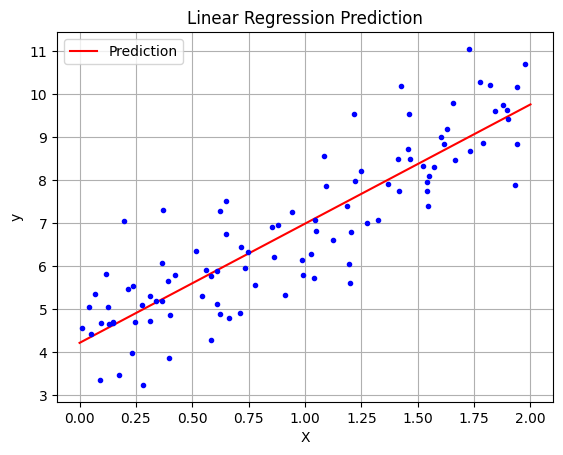

In [ ]:
import matplotlib.pyplot as plt

plt.plot(X_new, y_predict, "r-", label="Prediction")
plt.plot(X, y, "b.")
# 레이블, 축 , 그리드 범례를 추가
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Prediction")
plt.grid(True)
plt.legend()
plt.show()

사이킷런에서 선형 회귀를 수행하는 것은 비교적 간단하다.

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [ ]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

사이킷런은 특성의 가중치(coef_)와 편향(intercept_)을 분리하여 저장함

LinearRegression 클래스는 scipy.linalg.lstsq() 함수('최소 제곱'에서 이름을 따왔음)를 기반으로 함. 다음과 같이 이 함수를 직접 호출할 수 있음

In [ ]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

이 함수는 $ θ̂  = X^{+}y $를 계산한다.

$ X^{+}$는 $X$의 유사역행렬이다.

np.linalg.pinv() 함수를 사용해 유사역행렬을 직접 구할 수 있다.



In [ ]:
np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

유사역행렬 자체는 **특잇값 분해**(SVD)라 부르는 표준 행렬 분해 기법을 사용해 계산됨.

SVD는 훈련 세트 행렬 X를 3개의 행렬 곱셉 $UΣVᵀ$로 분해함

유사역행렬은 $X^{+} = VΣUᵀ$ 로 계산됨. $Σ^+$를 계산하기 위해 알고리즘이 Σ를 먼저 수한 다으므 어떤 낮은 임곗값보다 작은 모둔 수를 0으로 바꿈.

그 다음 0이 아닌 모든 값을 역수로 치환함. 마지막으로 만들어진 행렬을 전치함.
정류 방정식을 계산하는 것보다 이 방식이 훨씬 효율적이고 극단적인 경우도 처리 가능

실제로 m<n이거나 어떤 특성이 중복되어 행렬 XᵀX의 역행렬이 없다면(= 특이 행렬이라면) 정규 방정식이 작동하지 않음. 하지만 유사역행렬을 항상 구할 수 있음

### 4.1.2 계산 복잡도

정규 방정식은 (n+1)×(n+1) 크기의 XᵀX의 역행렬을 계산한다 (n은 특성 수)

역행렬을 계산하는 계산 복잡도는 일반적으로 O(n^2.4)에서 O(n^3) 사이이다.

→ 다시 말해 특성 수가 두 배로 늘어나면 계산 시간이 대략 5.3에서 8배로 증가함

사이킷런의 LinearRegression 클래스가 사용하는 SVD 방법은 약 O(n^2)이다.

→ 특성의 개수가 두 배로 늘어나면 계산 시간은 대략 4배가 됨.

---
## 4.2 경사 하강법

경사 하강법(GD)은 여러 종류의 문제에서 최적의 해법을 찾을 수 있는 일반적인 최적화 알고리즘이다.

경사 하강법의 기본 아이디어는 비용 함수를 최소화하기 위해 반복해서 파라미터를 조정해감

1. 파라미터 벡터 θ 에 대해 비용 함수의 현재 그래디언트를 계산함
2. 그래디언트가 감소하는 방향으로 진행
3. 그래디언트가 0이 되면 최솟값에 도달한것임

구체적으로 본다면 θ를 임의의 값으로 시작해서(**랜덤 초기화**) 한 번에 조금씩 비용 함수(ex) MSE)가 감소되는 방향으로 진행하여 알고리즘이 최솟값에 수렴할 떄까지 점진적으로 향상시킴

경사 하강법에서 중요한 파라미터는 스템의 크기 = 학습률 하이퍼파라미터로 결정

- 학습률이 너무 작으면 알고리즘이 수렴하기 위해 반복을 많이 진행해야해서 시간이 오래 걸림
- 학습률이 너무 크면 골짜기를 가로질러 이전보다 더 높은 곳으로 올라가 알고리즘을 더 큰 값으로 발산하게 됨

모든 비용 함수가 그릇형태가 아니기에 여러 지형이 있으면 최솟값으로 수렴하기 매우 어려움

→ 전역 최솟값 이전에 지역 최솟값이 있는 상태에서 알고리즘을 시작하면 지역 최솟값에 수렴함

다행히 선형 회귀를 위한 MSE 비용 함수는 곡선에서 어떤 두 점을 선택해 선을 그어도 곡선을 가로지르지 않는 볼록 함수임

→ 지역 최솟값 X  전역 최솟값만 있음


**결국 모델 훈련은 훈련 세트에서 비용 함수를 최소화하는 모델 파라미터의 조합을 찾는 일 = 모델의 파라미터 공간에서 찾는다**


### 4.2.1 배치 경사 하강법

- 편도함수 : 경사 하강법을 구현하려면 각 모델 파라미터에 대해 비용 함수의 그레이디언트를 계산해야하는데, 파라미터가 조금 변경될 때 비용 함수가 얼마나 바뀌는지 계산해야하고 그 함수가 편도함수임 → 이걸 모든 차원에 대해 반복

- 비용 함수의 편도함수
$$ \frac{∂}{∂θ_j} MSE(θ) = \frac{2}{m} \Sigma^{m}_{i=1} (θ^T𝚇^{(i)} - y^{(i)})x^{(i)}_j $$

편도 함수를 각각 계산하는 대신 밑의 식을 사용하여 한꺼번에 계산 가능함

그레이디언트 벡터 $ ∇_θ MSE(θ) $는 비용함수의 (모델 파라미터마다 한 개씩인) 편도함수를 모두 담고 있음

$$ ∇_θ MSE(θ) = \begin{pmatrix}
\frac{∂}{∂θ_j} MSE(θ) \\
\frac{∂}{∂θ_j} MSE(θ) \\
… \\
\frac{∂}{∂θ_j} MSE(θ)
\end{pmatrix} = \frac{2}{m} 𝐗^T(𝐗θ - y) $$


위로 향하는 그레이디언트 벡터가 구해지면 반대 방향인 아래로 가야 함

θ에서 $ ∇_θ MSE(θ) $를 빼야 한다는 뜻 → 여기서 학습률인 η가 사용됨

내려가는 스텝의 크기를 결정하기 위해 그레이디언트 벡터에 η를 곱함

$$ θ^{(next step)} = θ - η∇_θMSE(θ) $$

이 알고리즘을 간단히 구현해보자면

In [ ]:
import numpy as np

eta = 0.1 # 학습률
n_epochs = 1000
m = len(X_b) # 샘플 개수

#  y가 1차원 배열(m,)일 경우 2차원 열벡터(m, 1)로 변환해 줍니다.
y = y.reshape(-1, 1)

np.random.seed(42)
theta = np.random.randn(2, 1) # 모델 파라미터 초기화 (2, 1)

for epoch in range(n_epochs):
    # gradients 구하는 공식: (2/m) * X_b.T @ (X_b @ theta - y)
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

print("최종 theta:\n", theta)

최종 theta:
 [[4.21509616]
 [2.77011339]]


훈련 세트를 한 번 반복하는 것을 epoch라고 함

학습률을 바꿔보자 !

- 학습률이 너무 낮으면 알고리즘은 최적점에 도달하겠지만 시간이 오래 걸림
- 적당하면 반복 몇 번만에 바로 최적점에 수렴함
- 너무 높으면 알고리즘이 이리저리 널뛰면서 스텝마다 최적점에서 점점 더 멀어져 발산함

적절한 학습률을 찾기 위해서 그리드 서치를 사용함

하지만 그리드 서치에서 수렴하는 데 너무 오래 걸리는 모델이 제외될 수 있도록  반복 횟수를 제한해야 함

- 반복 횟수가 너무 작으면 최적점에 도달하기 전에 알고리즘이 멈춤
- 너무 크면 모델 파라미터가 더는 변하지 않는 동안 시간을 낭비하게 됨

간단한 해결책은 반복 횟수를 아주 크게 지정하고 그레이디언트 벡터가 아주 작아지면 = 벡터의 노름이 허용오차(ϵ)보다 작아집면

경사 하강법이 최솟값에 도달함 → 알고리즘을 중지

### 4.2.2 확률적 경사 하강법

배치 경사 하강법의 문제는 매 스텝에서 전체 훈련세트를 씀 → 매우 느림

**확률적 경사 하강법은 매 스텝에서 한 개의 샘플을 랜덤으로 선택하고 그 하나의 샘플에 대한 그레이디언트를 계산함 → 확실히 빠름 **

but 배치 경사 하강법 보단 훨씬 불안정함

비용함수가 최솟값에 다다를 때까지 요동치며 평균적으로 감소 → 최적치가 아님

- 비용함수가 매우 불규칙할 때 알고리즘이 지역 최솟값을 건너뛰도록 도와줌
- 확률적 경사 하강법이 배치 경사 하강법 보다 전역 최솟값을 찾을 가능성이 높음





무작위성
- 지역 최솟값에서 탈출시켜줌
- but 알고리즘을 전역 최솟값에 다다르지 않게 한다는 점에 안좋음

→ **학습률을 점진적으로 감소시켜서 해결**





시작할 때 학습률을 크게 함 → 수렴을 빠르게 하고 지역 최솟값에 빠지지 않게 함

점차 작게 줄임 → 알고리즘이 전역 최솟값에 도달하게 함

*= 담금질 기법 알고리즘과 유사*

- 학습 스케줄 : 매 반복에서 학습률을 결정하는 함수

In [ ]:
import numpy as np

n_epochs = 50
t0, t1 = 5, 50  # 학습 스케줄 하이퍼파라미터

# 샘플 개수 m 및 데이터 정의 (X_b와 y가 미리 정의되어 있다고 가정)
m = len(X_b)

# y를 2차원 열벡터(m, 1) 형태로 확실히 변환해 줍니다.
y = y.reshape(-1, 1)

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)  # 모델 파라미터 랜덤 초기화

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = np.random.randint(m)

        # 슬라이싱(random_index : random_index + 1)을 써야 (1, 2) 차원이 유지됨
        xi = X_b[random_index:random_index + 1]
        yi = y[random_index:random_index + 1]

        # gradients: (2, 1) @ ((1, 2) @ (2, 1) - (1, 1)) -> (2, 1) 차원 정상 계산
        gradients = 2 * xi.T @ (xi @ theta - yi)

        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

print("최종 theta:\n", theta)

최종 theta:
 [[4.21076011]
 [2.74856079]]


- epoch = 한 반복에서 m번 되풀이 되는데, 각 반복을 에포크라고 함



### 4.2.3 미니배치 경사 하강법

**미니배치**라 부르는 임의의 작은 샘플 세트에 대해 그레이디언트를 계산

- 장점 : GPU를 사용해서 성능 향상 가능
- 미니배치를 어느 정도 크게 하면 알고리즘이 파라미터 공간에서 SGD보다 덜 불규칙하게 움직임
- → but 지역 최솟값에서 빠져나오기는 더 힘들지도 ㅎㅎ



|알고리즘|m이 클 때|외부 메모리 학습 지원|n이 클 때|하이퍼파라미터 수|스케일 조정 필요|사이킷런|
|--------|--------|-------------|---------|--------------|-----------|--------|
|정규 방정식|빠름|No|느림|0|No|N/A|
|SVD|빠름|No|느림|0|No|Linear Regression|
|배치 경사 하강법|느림|No|빠름|2|Yes|N/A|
|확률적 경사 하강법|빠름|Yes|빠름|≥ 2|Yes|SGDRegressor|
|미니배치 경사 하강법|빠름|Yes|빠름|≥ 2|Yes|N/A|

---
## 4.3 다항 회귀

비선형 데이터를 학습하는데 선형 모델을 사용 ㄱㄴ → 각 특성의 거듭제곱을 새로운 특성으로 추가

= 이런 기법이 다항 회귀임

In [ ]:
# 예를 들어 간단한 2차 방정에 약간의 잡음을 추가한 비선형 데이터 생성

#np.random.seed(42)
#m = 100
#X = 6 * np.random.rand(m, 1) - 3
#y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

아니면 사이킷런의 PolynomialFeatures 를 사용해 훈련 데이터 변환도 ㄱㄴ
- 훈련 세트에 있는 각 특성을 제곱하여 새로운 특성으로 추가 (여기서는 특성 하나가 추가됨)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
x_poly  = poly_features.fit_transform(X)
X[0]

In [ ]:
#X_poly[0]
# X_poly 는 이제 원래 특성 X 와 이 특성의 제곱을 포함함

In [ ]:
# 여기에 Linear Regression 적용하면
#from sklearn.linear_model import LinearRegression
#lin_reg = LinearRegression()
#lin_reg.fit(X_poly, y)
#lin_reg.intercept_, lin_reg.coef_

특성이 여러 개일 때 다항 회귀는 특성 사이의 관계를 찾을 수 있음 (일반적인 선형 회귀 모델에선  X)

→ 폴리노미알피쳐스가 주어진 차수까지 특성 간의 모든 교차항을 추가하기 때문





---
## 4.4 학습 곡선

고차 다항 회귀를 적용하면 일반 선형 회귀보다 훨씬 더 훈련 데이터에서 잘 맞추려 할 거임
→ 훈련 데이터에 과대적합될 가능성 있

근데 일반적으로 어떤 함수로 데이터가 생성됐는지는 모름

→ 얼마나 복잡한 모델을 사용할지 어떻게 결정할 수 있을까?

→ 어떻게 모델이 데이터에 과대적합 또는 과소적합되었는지 알 수 있을까?



2장 (+ 내 xai 연구)에서는 교차 검증을 사용

또 다른 방법은 학습 곡선을 확인하는 것 !!

- **학습 곡선** : 모델의 훈련 오차와 검증 오차를 훈련 반복 횟수의 함수로 나타낸 그래프
- 훈련하는 동안 훈련 세트와 검증 세트에서 일정한 간격으로 모델을 평가하고 그 결과를 그래프로 그리면 됨

사이킷런의 learning_curve() 함수 : 훈련 세트의 크기를 증가시키면서 모델을 재훈련
- 모델이 점진적 학습을 지원하는 경우 :
- learning_curve()를 호출할 때 exploitd_incremental_learning=True로 지정하면 대신 모델을 점진적으로 훈련시킴
- 모델을 평가한 훈련 세트 크기를 반환
- 각각의 크기와 교차 검증 폴드에서 측정한 훈련 및 검증 점수를 반환

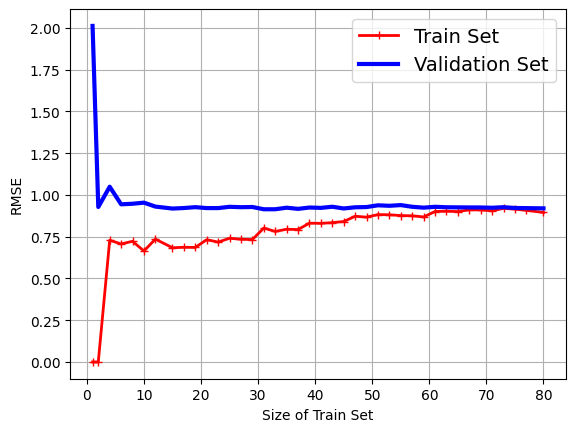

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve

train_sizes, train_scores, validation_scores = learning_curve(
    LinearRegression(), X, y,
    train_sizes=np.linspace(0.01, 1.0, 40),
    cv=5,
    scoring='neg_root_mean_squared_error'
)

train_errors = -train_scores.mean(axis=1)
valid_errors = -validation_scores.mean(axis=1)  # validation_scores로 수정

plt.plot(train_sizes, train_errors, 'r-+', linewidth=2, label='Train Set')
plt.plot(train_sizes, valid_errors, 'b-', linewidth=3, label='Validation Set')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('Size of Train Set')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

---
## 4.5 규제가 있는 선형 모델

과대적합을 줄이는 좋은 방법은 모델을 규제(=제한)하는 것

자유도를 줄이면 데이터에 과대적합되기 어려워짐. 다항 회귀 모델에서 규제하는 간단한 방법은 다항식의 차수를 줄이는 것

### 4.5.1 릿지 회귀

**릿지 회귀**는 **규제가 추가된 선형 회귀 버전**

규제항 $ \frac{α}{m} ∑^{n}_{i=1}θ^2_i$이 MSE에 추가됨

→ 학습 알고 리즘을 데이터에 맞추는 것 + 모델의 가중치가 가능한 한 작게 유지되도록 함

규제항은 훈련하는 동안에만 비용 함수에 추가됨 → 모델의 훈련이 끝나면 모델의 성능을 규제가 없는 MSE로 평가

하이퍼파라미터α는 모델을 얼마나 많이 규제할지 조절
- α=0 이면 릿지 회귀는 선형 회귀와 같아짐
- α가 아주 크면 모든 가중치가 거의 0에 가까워지고 데이터의 평균을 지나면 수평선이 됨

$ J(θ) = MSE(θ) + \frac{α}{m} \sum^{n}_{i=1} θ^2_i $

릿지 회귀의 정규 방정식

$ \hatθ = (𝐗^T𝐗 + α𝐀)^{-1} 𝐗^Ty $

### 4.5.2 라쏘 회귀

**라쏘 회귀**는 릿지 회귀처럼 비용 함수에 규제항을 더하지만, $ℓ_2$ 노름 대신 가중치 벡터의 $ℓ_1$ 노름을 사용함

$ ℓ_1$ 노름에는 2α를 곱했지만 릿지 회귀에서는 $ℓ_1$ 노름에는 α/m를 곱함



라쏘 회귀의 비용 함수

$ J(θ) = MSE(θ) + 2α\sum_{i=1}^{n} |θ_i| $

라쏘 회귀의 중요한 특징 → 덜 중요한 특성의 가중치를 제거하려고 함 (= 가중치가 0이 됨)

→ 자동으로 특성 선택을 수행하고 **희소 모델**을 만듬 (= 0이 아닌 특성의 가중치가 적음)



라쏘의 비용 함수는 θᵢ=0 에서 미분 가능하지 않음

→ 서브그레이디언트 벡터 g 사용하면 경사 하강법을 적용하는 데 문제가 없음



In [ ]:
# 라쏘 클래스를 사용한 간단한 사이킷런 예제
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X,y)
lasso_reg.predict([[1.5]])

# Lasso 대신 SGDRegressor(penalty='l1', alpha=0.1)

### 4.5.3 엘라스틱넷

엘라스틱넷 회귀는 릿지 회귀와 라쏘 회귀를 절충한 모델

규제항은 릿지와 회귀의 규제항을 단순히 더한 것, 혼합 정도는 혼합 비율 r을 사용해 조절

r=0 → 릿지 회귀, r=1 → 라쏘 회귀

특성 수가 훈련 샘플 수보다 많거나 특성 몇 개가 강하게 연관되어 있을 때는 보통 라쏘가 문제를 일으키므로 엘라스틱넷이 좋음



In [ ]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

### 4.5.4 조기 종료

**조기종료** = 검증 오차가 최솟값에 도달하면 바로 훈련을 중지시킴



In [ ]:
 from copt import deepcopy
 from sklearn.metrics import mean_squared_error
 form sklearn.preprocessing import StandardScaler

 X_train, y_train, X_valid, y_valid = [...] # 2차 방정식 데이터셋읕 나눔

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False), StandardScaler())

X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')

for epoch ion rangeE(n_epochs):
  sgd_reg.partial_fit(X_train_prep, y_train)
  y_valid_predict = sgd_reg.predict(X_valid_prep)
  val_error = mean_squared_error(y_valid, y_valid_predict, squared=False)
  if val_error < best_valid_rmse:
    best_valid_rmse = val_error
    best_model = deepcopy(sgd_reg)

이 코드는 먼저 다항 특성을 추가하고 훈련 세트와 검증 세트 모두에 대해 모든 입력 특성의 스케일을 조정함

그런 다음 규제가 없고 학습률이 작은  SGDRegressor 모델을 생성함

훈련 반복에선 fit() 대신 partial_fit() 을 호출하여 점진적인 학습을 수행함

---
## 4.6 로지스틱 회귀

**로지스틱 회귀**는 샘플이 특정 클래스에 속할 확률을 **추정**하는데 사용됨

추정 확률이 주어진 임곗값(보통 50%)보다 크면 모델은 그 샘플이 해당 클래스에 속한다고 예측 : 양성 클래스 / 속하지 않는다고 예측 : 음성 클래스

- 양성 클래스 : 레이블이 '1'
- 음성 클래스 : 레이블이 '0'

### 4.6.1 확률 추정

작동법 : 입력 특성의 가중칭 합 계산, 편향 더함

→ **로지스틱** 출력 (결과 출력 X)

$ p̂= h_θ(𝚇) = σ(θ^T𝚇) $

**로지스틱**(σ)은 0과 1 사이의 값을 출력하는 **시그모이드 함수**임

$ σ(t) = \frac{1}{1+exp(-t)} $

로지스틱 회귀 모델이 샘플 x가 양성 클래스에 속할 확률 p̂를 추정하면 이에 대한 예측 ŷ를 쉽게 구할 수 있음

$ ŷ = \begin{cases}
0 \quad
p̂<0.5 \\
1 \quad
p̂ ≥ 0.5
\end{cases}$

t가 0보다 작으면 σ(t) ≥ 0.5 이므로 기본 임곗값인 50% 확률을 사용하는 로지스틱 회귀 모델은 $ θ^T𝚡 $가 양수일때 → 1, 음수일때 → 0

### 4.6.2 훈련과 비용 함수

훈련의 목적은 양성 샘플 (y=1)에 대해서는 높을 확률을 추정하고 음성 샘플 (y=0)에 대해서는 낮은 확률을 추정하는 모델의 파라미터 벡터 θ를 찾는 것

- 하나의 훈련 샘플 𝚡에 대한 비용 함수

$ c(θ) = \begin{cases}
-log(\hat p) \quad \quad \quad
y=1 일때 \\
-log(1- \hat p) \quad
y=0일때\end{cases}$

이 비용함수는 t가 0에 가까워지면 -log(t)가 매우 커지므로 타당 → 양성 샘플을 0에 가까운 확률로 추정하면 비용 ⇑


전체 훈련 세트에 대한 비용 함수는 모든 훈련 샘플의 비용을 평균 → **로그 손실**

$ J(\theta) = -\frac{1}{m} \sum^m_{i=1}[y^{(i)}log(\hat p^{(i)})+(1-y^{(i)})log(1-\hat p^{(i)})]$

이 비용 함수의 최솟값을 계산하는 알려진 해 X

하지만 이 비용 함수는 볼록 함수이므로 경사 하강법이 전역 최솟값을 찾는 것을 보장함

### 4.6.3 결정 경계


In [ ]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x = iris.data[["pedal width(cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

X_new = np.linspace(0, 3, 1000).reshape(-1, 1)  # 열 벡터로 바꿉니다.
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

decision boundary는 모델이 50% 확률을 추정하는 지점으로 모델의 결정 경계임 → **선형**

### 4.6.4 소프트맥스 회귀

로지스틱 회귀 모델은 직접 다중 클래스를 지원하도록 일반화 될 수 있음 → **소프트맥스 회귀** or **다항 로지스틱 회귀**

샘플 x가 주어지면 먼저 소프트맥스 회귀 모델이 각 클래스 k에 대한 점수 $ s_k(𝚡) = (θ^{(k)})^T𝚡$

를 계산하고 그 점수에 소프트맥스 함수를 적용하여 각 클래스의 확률을 추정함


각 클래스는 자신만의 파라미터 벡터가 있음

이 벡터들은 파라미터 행렬 Θ에 행으로 저장됨

샘플 x에 대해 각 클래스의 점수가 계산되면 소프트맥스 함수를 통과시켜 클래스 k에 속할 확률 p̂ₖ을 추정함

이 함수는 각 점수에 지수 함수를 적용한 후 정규화함 (모든 지수 함수 결과의 합으로 나눔)

→ 이 점수를 로짓 or 로그-오즈라고 부름
- 소프트맥스 함수
$ \hat p_k = σ(s(x))_k = \frac{exp(s_k(x))}{\sum_{j=1}^K} exp(s_j(x))$

- K = 클래스 수
- s(x) = 샘플 x에 대한 각 클래스의 점수를 담은 벡터입니다
- σ(s(x))ₖ 는 샘플 x에 대한 각 클래스의 점수가 주어졌을 때 이 샘플이 클래스 k 에 속할 추정 확률




소프트맥스 회귀 분류기는 추정확률이 가장 높은 클래스(= 가장 높은 점수를 가진 클래스)를 선택함

$ \hat y = argmax_k σ(s(x))_k = argmax_k s_k(x) = argmax_K((θ^{(k)})^T𝚡) $

argmax 연산은 함수를 최대화하는 변수의 값을 반환함


*소프트맥스 회귀 분류기는 한 번에 하나의 클래스만 예측함*

훈련 방법 → 모델이 타깃 클래스에 대해서는 높은 확률을 추정하도록 만드는 것이 목적

**크로스 엔트로피** 비용 함수를 최소화하는 것은 타깃 클래스에 대해 낮은 확률을 예측하는 모델을 억제하므로 이 목적에 부합함

$ J(Θ) = -\frac{1}{m} \sum_{i=1}^m \sum_{k=1}^K y_k^{(i)} log(\hat p_k^{(i)}) $

- $y_k^{(i)}$는 i번째 샘플이 클래스 k에 속할 타깃 확률
- 샘플이 클래스에 속하면 1
- 안속하면 0

## 4장 끝 !! ⋆ ⋆ ⋆